# COVID-19 X-ray Classification with Grad-CAM Explainability

This notebook is for exploratory data analysis, model prototyping, and quick visualization of Grad-CAM results.

**Objectives:**
- Explore the dataset
- Visualize sample images
- Test model predictions
- Generate and inspect Grad-CAM heatmaps
- Validate model focus areas

In [2]:
import sys
import os

# Add the project root directory to Python path so we can import from 'src'
project_root = 'D:/Research'   # Your project folder path
sys.path.append(project_root)

print("Project root added to Python path:")
print(project_root)
print("\nCurrent working directory:", os.getcwd())
print("\nPython can now import from 'src' folder!")

Project root added to Python path:
D:/Research

Current working directory: D:\Research\notebooks

Python can now import from 'src' folder!


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Import your project modules
from src.model import grad_cam
from src.utils import display_prediction_with_heatmap, load_and_preprocess_image

# -------------------------- Paths --------------------------
DATA_DIR = '../data/processed/test/'
MODEL_PATH = 'D:/Research/models/trained_model.h5'
RESULTS_DIR = 'results/heatmaps/exploratory/'
os.makedirs(RESULTS_DIR, exist_ok=True)

# -------------------------- Settings --------------------------
class_names = ['COVID', 'Normal', 'Pneumonia']

print("Setup complete!")

Setup complete!


## 1. Load the Trained Model

In [9]:
model = load_model(MODEL_PATH)
print("Model loaded successfully!")
model.summary()

Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 25,688,965 (98.00 MB)

 Trainable params: 25,635,843 (97.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 2 (12.00 B)

## 2. Explore Sample Images from Each Class

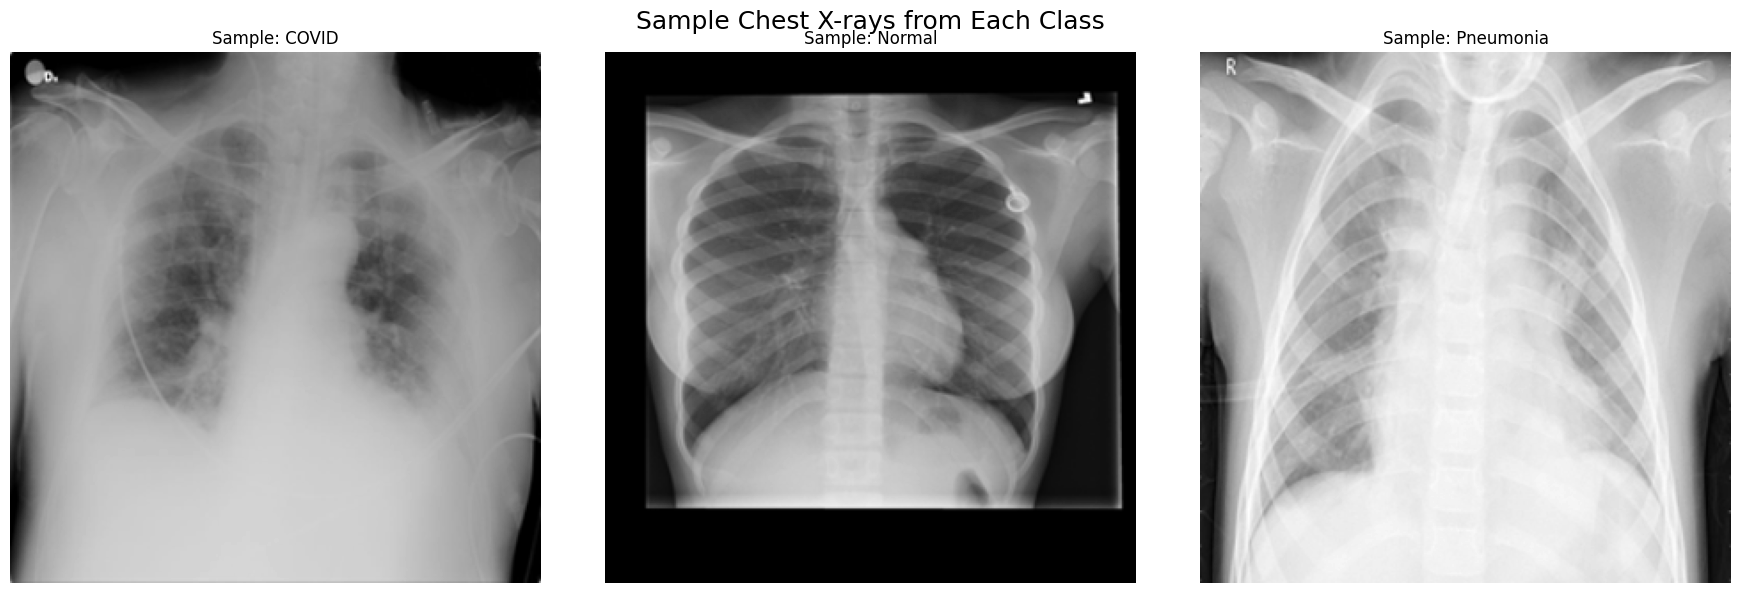

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, cls in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, cls)
    if not os.path.exists(class_path) or len(os.listdir(class_path)) == 0:
        axs[i].text(0.5, 0.5, f'No images found in {cls}', 
                    ha='center', va='center', fontsize=14, color='red')
        axs[i].set_title(cls)
    else:
        sample_img = os.listdir(class_path)[0]
        img_path = os.path.join(class_path, sample_img)
        img = plt.imread(img_path)
        axs[i].imshow(img, cmap='gray')
        axs[i].set_title(f'Sample: {cls}')
    axs[i].axis('off')

plt.suptitle('Sample Chest X-rays from Each Class', fontsize=18)
plt.tight_layout()
plt.show()

## 3. Test Grad-CAM on Selected Images

In [11]:
# Pick one representative image from each class (3rd image for variety)
sample_images = {}
for cls in class_names:
    class_path = os.path.join(DATA_DIR, cls)
    files = os.listdir(class_path)
    # Choose the 3rd image if available, otherwise the first
    selected_file = files[2] if len(files) > 2 else files[0]
    sample_images[cls] = os.path.join(class_path, selected_file)

print("Selected images for Grad-CAM analysis:")
for cls, path in sample_images.items():
    print(f"  {cls}: {os.path.basename(path)}")

Selected images for Grad-CAM analysis:
  COVID: COVID-1010.png
  Normal: Normal-10006.png
  Pneumonia: Viral Pneumonia-1019.png


In [12]:
for label, img_path in sample_images.items():
    print(f"\n{'='*60}")
    print(f"Processing: {os.path.basename(img_path)} (True label: {label})")
    print(f"{'='*60}")
    
    # Load and preprocess
    img_array, _ = load_and_preprocess_image(img_path)
    
    # Predict
    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_class = class_names[pred_idx]
    confidence = pred_probs[pred_idx] * 100
    
    # Generate heatmap
    heatmap = grad_cam(model, img_array)
    
    # Save path
    save_path = os.path.join(RESULTS_DIR, f'{label}_{os.path.basename(img_path)}_gradcam.png')
    
    # Display and save
    display_prediction_with_heatmap(
        original_img_path=img_path,
        heatmap=heatmap,
        prediction=pred_class,
        confidence=confidence,
        save_path=save_path
    )
    
    status = "✓ Correct" if pred_class == label else "✗ Incorrect"
    print(f"\nResult: {status}")
    print(f"True label: {label} | Predicted: {pred_class} ({confidence:.2f}% confidence)")
    print(f"Visualization saved to:\n{save_path}")


Processing: COVID-1010.png (True label: COVID)


D:\Research\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Visualization saved to results/heatmaps/exploratory/COVID_COVID-1010.png_gradcam.png

Result: ✓ Correct
True label: COVID | Predicted: COVID (99.93% confidence)
Visualization saved to:
results/heatmaps/exploratory/COVID_COVID-1010.png_gradcam.png

Processing: Normal-10006.png (True label: Normal)
Visualization saved to results/heatmaps/exploratory/Normal_Normal-10006.png_gradcam.png

Result: ✓ Correct
True label: Normal | Predicted: Normal (100.00% confidence)
Visualization saved to:
results/heatmaps/exploratory/Normal_Normal-10006.png_gradcam.png

Processing: Viral Pneumonia-1019.png (True label: Pneumonia)
Visualization saved to results/heatmaps/exploratory/Pneumonia_Viral Pneumonia-1019.png_gradcam.png

Result: ✓ Correct
True label: Pneumonia | Predicted: Pneumonia (99.74% confidence)
Visualization saved to:
results/heatmaps/exploratory/Pneumonia_Viral Pneumonia-1019.png_gradcam.png


## 4. Clinical Validation Notes

Open the saved PNG files in `results/heatmaps/exploratory/` and record your observations below:

**Observations:**

- **COVID cases**: Does the red/yellow activation focus on bilateral lower lung zones, ground-glass opacities, or peripheral areas?

- **Normal cases**: Is there minimal or no strong activation in the lung fields?

- **Pneumonia cases**: Does the model highlight consolidation or opaque regions?

- Overall: Is the model focusing on clinically relevant features or artifacts (bones, devices, text)?

**Your notes here (replace this text):**

---

---

These findings support the model's transparency and can be used in your research paper to demonstrate improved trust over black-box systems.